## IMPORTACION DE LIBRERIAS

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from google.colab import files

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

sns.set(style="whitegrid")


##2. CARGAR DATASET LIMPIO

In [4]:
uploaded = files.upload()


Saving data_isp_model_ready.csv to data_isp_model_ready.csv


In [5]:
df = pd.read_csv("data_isp_model_ready.csv")
print("Dataset cargado correctamente")
print("Shape:", df.shape)
df.head()


Dataset cargado correctamente
Shape: (10000, 15)


,velocidad_contratada_mbps,distancia_central_km,potencia_rx_dbm,latencia_ms,perdida_paquetes_pct,jitter_ms,uso_ancho_banda_pct,quejas_recientes,antiguedad_meses,riesgo_degradacion_servicio,distrito_Comas,distrito_Independencia,distrito_Los Olivos,distrito_Puente Piedra,distrito_San Martin de Porres
0,200,1.61,-17.94,14.80,1.19,3.42,89.59,1,26,0,0,1,0,0,0
1,300,2.05,-21.27,8.85,4.11,1.42,30.34,0,69,0,0,1,0,0,0
2,200,6.93,-27.01,2.63,0.97,3.57,82.46,1,49,0,0,1,0,0,0
3,100,6.32,-16.56,5.66,2.75,1.16,58.73,3,12,1,0,0,0,0,0
4,500,11.54,-15.67,16.33,2.30,0.39,58.79,0,60,0,1,0,0,0,0


## 3. SEPARAR X y Y

In [6]:
target = "riesgo_degradacion_servicio"

X = df.drop(columns=[target])
y = df[target]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)

print("\nDistribución de clases:")
display(y.value_counts())
display((y.value_counts(normalize=True) * 100).round(2))


Shape de X: (10000, 14)
Shape de y: (10000,)

Distribución de clases:


,count
riesgo_degradacion_servicio,
0,9121
1,879


,proportion
riesgo_degradacion_servicio,
0,91.21
1,8.79


## 4. DIVICION TRAIN/TEST

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)


X_train: (7000, 14)
X_test: (3000, 14)


## 5. DEFINIR MODELOS

In [8]:
models = {
    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            class_weight="balanced",
            random_state=42,
            max_iter=2000
        ))
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_split=5,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(
            kernel="rbf",
            probability=True,
            class_weight="balanced",
            random_state=42
        ))
    ]),

    "KNN": Pipeline([
        ("scaler", StandardScaler()),
        ("model", KNeighborsClassifier(n_neighbors=7))
    ])
}


##6. ENTRENAR Y COMPARAR

In [9]:
results = {}
trained_models = {}

for name, pipeline in models.items():
    pipeline.fit(X_train, y_train)
    trained_models[name] = pipeline

    y_pred = pipeline.predict(X_test)

    if hasattr(pipeline, "predict_proba"):
        y_prob = pipeline.predict_proba(X_test)[:, 1]
    else:
        y_prob = None

    results[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, y_prob) if y_prob is not None else np.nan
    }

results_df = pd.DataFrame(results).T.sort_values(by=["F1", "Recall"], ascending=False)
print("Comparación de modelos:")
display(results_df)


Comparación de modelos:


,Accuracy,Precision,Recall,F1,ROC_AUC
Logistic Regression,0.678333,0.173346,0.704545,0.278235,0.756472
SVM,0.687000,0.172012,0.670455,0.273782,0.729061
KNN,0.909333,0.214286,0.011364,0.021583,0.628560
Random Forest,0.911667,0.000000,0.000000,0.000000,0.726852


##7. ELEGIR EL MEJOR MODELO

In [10]:
best_model_name = results_df.index[0]
best_model = trained_models[best_model_name]

print("Mejor modelo:", best_model_name)
print(results_df.loc[best_model_name])


Mejor modelo: Logistic Regression
Accuracy     0.678333
Precision    0.173346
Recall       0.704545
F1           0.278235
ROC_AUC      0.756472
Name: Logistic Regression, dtype: float64


##8. EVALUACION A DETALLE

In [11]:
y_pred_best = best_model.predict(X_test)

if hasattr(best_model, "predict_proba"):
    y_prob_best = best_model.predict_proba(X_test)[:, 1]
else:
    y_prob_best = None

print(classification_report(y_test, y_pred_best))


              precision    recall  f1-score   support

           0       0.96      0.68      0.79      2736
           1       0.17      0.70      0.28       264

    accuracy                           0.68      3000
   macro avg       0.57      0.69      0.54      3000
weighted avg       0.89      0.68      0.75      3000



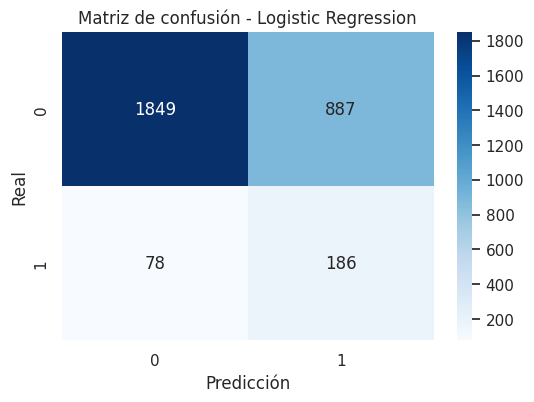

In [12]:
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.title(f"Matriz de confusión - {best_model_name}")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()


##9. IMPORTANCIA DE VARIABLE

In [13]:
if best_model_name == "Random Forest":
    rf_model = best_model.named_steps["model"]
    importances = pd.DataFrame({
        "feature": X.columns,
        "importance": rf_model.feature_importances_
    }).sort_values(by="importance", ascending=False)

    display(importances.head(15))

    plt.figure(figsize=(8,5))
    sns.barplot(data=importances.head(15), x="importance", y="feature")
    plt.title("Top 15 variables más importantes")
    plt.show()


In [14]:
if best_model_name == "Logistic Regression":
    lr_model = best_model.named_steps["model"]
    coef_df = pd.DataFrame({
        "feature": X.columns,
        "coef": lr_model.coef_[0]
    }).sort_values(by="coef", key=np.abs, ascending=False)

    display(coef_df.head(15))


,feature,coef
2,potencia_rx_dbm,-0.944339
7,quejas_recientes,0.385048
4,perdida_paquetes_pct,0.352388
3,latencia_ms,0.282793
5,jitter_ms,0.165711
13,distrito_San Martin de Porres,-0.053455
10,distrito_Independencia,0.044470
6,uso_ancho_banda_pct,-0.033472
8,antiguedad_meses,-0.026464
11,distrito_Los Olivos,0.025186


##10. GUARDAR MODELO PARA FLASK

In [15]:
joblib.dump(best_model, "isp_risk_model.pkl")
joblib.dump(list(X.columns), "isp_feature_columns.pkl")

print("Archivos guardados correctamente")


Archivos guardados correctamente


In [16]:
files.download("isp_risk_model.pkl")
files.download("isp_feature_columns.pkl")


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

##11. PROBAR UNA PREDICCION NUEVA

In [17]:
model = joblib.load("isp_risk_model.pkl")
feature_columns = joblib.load("isp_feature_columns.pkl")


In [18]:
def predict_risk(new_data: dict):
    input_df = pd.DataFrame([new_data])
    input_df = input_df.reindex(columns=feature_columns, fill_value=0)

    pred_class = model.predict(input_df)[0]

    if hasattr(model, "predict_proba"):
        pred_prob = model.predict_proba(input_df)[0][1]
    else:
        pred_prob = None

    return pred_class, pred_prob


In [22]:
sample_input = {
    "velocidad_contratada_mbps": 200,
    "distancia_central_km": 8.5,
    "potencia_rx_dbm": -25.0,
    "latencia_ms": 17.0,
    "perdida_paquetes_pct": 3.5,
    "jitter_ms": 4.0,
    "uso_ancho_banda_pct": 85.0,
    "quejas_recientes": 2,
    "antiguedad_meses": 18,
    "distrito_Comas": 1,
    "distrito_Independencia": 0,
    "distrito_Los Olivos": 0,
    "distrito_Puente Piedra": 0,
    "distrito_San Martin de Porres": 0
}

pred_class, pred_prob = predict_risk(sample_input)

print("Clase predicha:", pred_class)
print("Probabilidad de riesgo:", pred_prob)


Clase predicha: 1
Probabilidad de riesgo: 0.8192747949790705
